# Algoritmo básico - Monte Carlo

1. Identificar a quantidade de interesse na forma:
$$ \theta = \mathbb{E}[g(X)] $$
2. Determinar a distribuição de probabilidade de $X$.
3. Gerar $N$ realizações independentes $X_1, \dots, X_N$.
4. Avaliar $g(X_1), \dots, g(X_N)$.
5. Calcular:
$$ \hat{\theta}_N = \frac{1}{N}\sum_{i=1}^{N} g(X_i) $$
6. Aumentar $N$ e analisar a convergência numérica do estimador.

---

## Exercício 1 - Integração numérica por Monte Carlo

Considere $Z \sim \mathcal{N}(0,1)$ com $f_Z(z) = \frac{1}{\sqrt{2\pi}}e^{-z^2/2}$.

### a) Valor de referência pela tabela Normal padrão

Da tabela da distribuição Normal padrão,

$$
P(0 \le Z \le 1{,}96) \;=\; \Phi(1{,}96) - \Phi(0) \;=\; 0{,}9750 - 0{,}5000 \;=\; 0{,}4750 .
$$

Esse é exatamente o valor da integral que se deseja estimar, pois

$$
I \;=\; \frac{1}{\sqrt{2\pi}}\int_{0}^{1{,}96} e^{-z^{2}/2}\,dz \;=\; P(0 \le Z \le 1{,}96).
$$

Adota-se o valor de tabela $I = 0{,}4750$ como referência nos itens (e) a (g).

---

### b) Reescrita da integral como valor esperado

Seja $X \sim U(0;\,1{,}96)$. Sua densidade é

$$
f_X(x) \;=\; \frac{1}{b-a} \;=\; \frac{1}{1{,}96}, \qquad 0 \le x \le 1{,}96,
$$

e nula fora do intervalo. Definindo $h(x) = e^{-x^{2}/2}$, a Lei do Estatístico Inconsciente fornece

$$
\mathbb{E}\!\left[h(X)\right] \;=\; \int_{-\infty}^{\infty} h(x)\,f_X(x)\,dx
\;=\; \frac{1}{1{,}96}\int_{0}^{1{,}96} e^{-x^{2}/2}\,dx .
$$

Isolando a integral,

$$
\int_{0}^{1{,}96} e^{-x^{2}/2}\,dx \;=\; 1{,}96\;\mathbb{E}\!\left[e^{-X^{2}/2}\right],
$$

e substituindo na definição de $I$,

$$
\boxed{\;I \;=\; \frac{1}{\sqrt{2\pi}}\int_{0}^{1{,}96} e^{-x^{2}/2}\,dx \;=\; \frac{1{,}96}{\sqrt{2\pi}}\;\mathbb{E}\!\left[e^{-X^{2}/2}\right].\;} \qquad \blacksquare
$$

Trata-se do caso particular de $I = (b-a)\,\mathbb{E}[h(X)]$ com $a = 0$ e $b = 1{,}96$, multiplicado pela constante $1/\sqrt{2\pi}$.

---

### c) Obtenção do estimador de Monte Carlo pela LFGN

Seja $g(x) = e^{-x^{2}/2}$ e $\theta = \mathbb{E}[g(X)]$. Gerando $X_1,\dots,X_N \overset{\text{i.i.d.}}{\sim} U(0;\,1{,}96)$ e definindo $Y_i = g(X_i)$:

1. $g$ é contínua, logo Borel-mensurável; portanto $Y_1,\dots,Y_N$ também são i.i.d.
2. No intervalo considerado vale $0 < g(x) \le 1$, de modo que $\mathbb{E}[|Y|] < \infty$ e $\operatorname{Var}(Y) = \sigma_g^{2} < \infty$.

As hipóteses da Lei Fraca dos Grandes Números estão satisfeitas, portanto

$$
\frac{1}{N}\sum_{i=1}^{N} g(X_i) \;\overset{P}{\longrightarrow}\; \mathbb{E}[g(X)] = \theta .
$$

Multiplicando pela constante $c = 1{,}96/\sqrt{2\pi}$ e usando o resultado do item (b), $c\,\theta = I$, obtém-se o estimador

$$
\boxed{\;\hat{I}_N \;=\; \frac{1{,}96}{N\sqrt{2\pi}} \sum_{i=1}^{N} e^{-X_i^{2}/2} \;\overset{P}{\longrightarrow}\; I .\;}
$$

**Não-viés.** Como os $X_i$ são identicamente distribuídos,

$$
\mathbb{E}\!\left[\hat{I}_N\right] \;=\; \frac{c}{N}\sum_{i=1}^{N} \mathbb{E}\!\left[g(X_i)\right] \;=\; c\,\mathbb{E}[g(X)] \;=\; I .
$$

**Variância.** Pela independência dos $X_i$,

$$
\operatorname{Var}\!\left(\hat{I}_N\right) \;=\; c^{2}\,\frac{\operatorname{Var}\!\left(g(X)\right)}{N} \;=\; \frac{1{,}96^{2}}{2\pi}\cdot\frac{\sigma_g^{2}}{N}.
$$

Os dois momentos de $g(X)$ saem da mesma tabela usada no item (a). O primeiro é imediato, pela Lei do Estatístico Inconsciente:

$$
\mathbb{E}[g(X)] \;=\; \frac{1}{1{,}96}\int_{0}^{1{,}96} e^{-x^{2}/2}\,dx
\;=\; \frac{\sqrt{2\pi}}{1{,}96}\,P(0 \le Z \le 1{,}96)
\;=\; \frac{2{,}5066 \times 0{,}4750}{1{,}96} \;=\; 0{,}60747 .
$$

Para o segundo, a mudança de variável $u = x\sqrt{2}$, com $dx = du/\sqrt{2}$, recai na mesma integral tabelada:

$$
\int_{0}^{1{,}96} e^{-x^{2}}dx \;=\; \frac{1}{\sqrt{2}}\int_{0}^{2{,}7719} e^{-u^{2}/2}\,du
\;=\; \sqrt{\pi}\;P(0 \le Z \le 2{,}7719) \;=\; 1{,}7725 \times 0{,}4972 \;=\; 0{,}88129 ,
$$

usando $\Phi(2{,}77) = 0{,}9972$ na tabela. Logo

$$
\mathbb{E}[g(X)^{2}] \;=\; \frac{0{,}88129}{1{,}96} \;=\; 0{,}44964 ,
$$

e, pela identidade $\operatorname{Var}(W) = \mathbb{E}[W^{2}] - \mathbb{E}[W]^{2}$,

$$
\sigma_g^{2} \;=\; 0{,}44964 - 0{,}60747^{2} \;=\; 0{,}08062 .
$$

Com $c^{2} = 1{,}96^{2}/2\pi = 0{,}61141$, resulta

$$
N \cdot \operatorname{Var}\!\left(\hat{I}_N\right) = c^{2}\sigma_g^{2} = 0{,}04929
\qquad \Longrightarrow \qquad
\sigma_{\hat{I}_N} = \frac{0{,}2220}{\sqrt{N}} .
$$

Avaliando as duas integrais por quadratura em vez da tabela, obtém-se $c^{2}\sigma_g^{2} = 0{,}049285$ e $\sigma_{\hat{I}_N} = 0{,}222002/\sqrt{N}$, que coincidem com a conta manual até a quarta casa decimal. São esses os valores usados como referência nos itens (e) e (g).

O erro estatístico decresce, portanto, com $1/\sqrt{N}$.

d) e e) estimativas e erro absoluto:
N = 10^2: I_hat = 0.496694, e_N = 0.021694, sigma = 0.022200, e_N/sigma = 0.98
N = 10^3: I_hat = 0.477450, e_N = 0.002450, sigma = 0.007020, e_N/sigma = 0.35
N = 10^4: I_hat = 0.478385, e_N = 0.003385, sigma = 0.002220, e_N/sigma = 1.52
N = 10^5: I_hat = 0.474840, e_N = 0.000160, sigma = 0.000702, e_N/sigma = 0.23
N = 10^6: I_hat = 0.474808, e_N = 0.000192, sigma = 0.000222, e_N/sigma = 0.87

f) e g) M = 100 repetições:
N = 10^2: média = 0.474185, Var = 4.4640e-04, N*Var = 0.044640
N = 10^3: média = 0.476175, Var = 6.0186e-05, N*Var = 0.060186
N = 10^4: média = 0.475301, Var = 4.4120e-06, N*Var = 0.044120
N = 10^5: média = 0.474973, Var = 5.1381e-07, N*Var = 0.051381


N = 10^6: média = 0.475023, Var = 5.7059e-08, N*Var = 0.057059

h) I_hat acumulado em N = 10^5: 0.475312


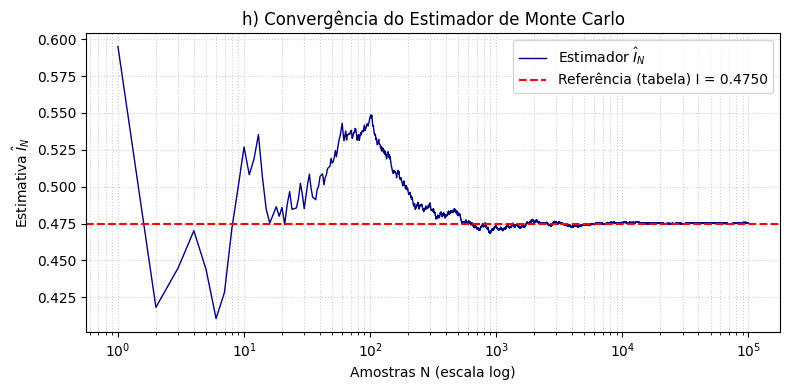

In [1]:
import numpy as np
import matplotlib.pyplot as plt

c = 1.96 / np.sqrt(2 * np.pi)     # constante do item (b)
I_ref = 0.4750                    # referência: tabela da Normal padrão, item (a)
c2_var_g = 0.049285               # c^2 * sigma_g^2, obtido no item (c)

# estimador de Monte Carlo com N amostras, itens (b) e (c)
def I_hat(N):
    X = np.random.uniform(0, 1.96, size=N)
    return c * np.mean(np.exp(-X**2 / 2))

# d) e e) estimador e erro absoluto para N = 10^2 ... 10^6
np.random.seed(42)
N_values = [10**2, 10**3, 10**4, 10**5, 10**6]
print("d) e e) estimativas e erro absoluto:")
for N in N_values:
    I_N = I_hat(N)
    e_N = abs(I_N - I_ref)
    sigma_N = np.sqrt(c2_var_g / N)
    print(f"N = 10^{int(np.log10(N))}: I_hat = {I_N:.6f}, e_N = {e_N:.6f}, "
          f"sigma = {sigma_N:.6f}, e_N/sigma = {e_N / sigma_N:.2f}")

# f) e g) M = 100 repetições por N
M = 100
print("\nf) e g) M = 100 repetições:")
for N in N_values:
    I_hats = [I_hat(N) for _ in range(M)]
    var = np.var(I_hats)
    print(f"N = 10^{int(np.log10(N))}: média = {np.mean(I_hats):.6f}, "
          f"Var = {var:.4e}, N*Var = {N * var:.6f}")

# h) convergência do estimador acumulado
N_max = 10**5
X = np.random.uniform(0, 1.96, size=N_max)
I_cum = c * np.cumsum(np.exp(-X**2 / 2)) / np.arange(1, N_max + 1)
print(f"\nh) I_hat acumulado em N = 10^5: {I_cum[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_max + 1), I_cum, color="navy", lw=1, label=r"Estimador $\hat{I}_N$")
plt.axhline(I_ref, color="red", linestyle="--", label=f"Referência (tabela) I = {I_ref:.4f}")
plt.xscale("log")
plt.xlabel("Amostras N (escala log)")
plt.ylabel(r"Estimativa $\hat{I}_N$")
plt.title("h) Convergência do Estimador de Monte Carlo")
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### e) Comportamento do erro absoluto

O item (c) forneceu $\sigma_{\hat{I}_N} = 0{,}222002/\sqrt{N}$, que é a magnitude típica do erro do estimador. Comparando com os erros obtidos:

| $N$ | $\hat{I}_N$ | $e_N$ obtido | $\sigma_{\hat{I}_N}$ | $e_N/\sigma_{\hat{I}_N}$ |
|---|---|---|---|---|
| $10^{2}$ | 0,496694 | 0,021694 | 0,022200 | 0,98 |
| $10^{3}$ | 0,477450 | 0,002450 | 0,007020 | 0,35 |
| $10^{4}$ | 0,478385 | 0,003385 | 0,002220 | 1,52 |
| $10^{5}$ | 0,474840 | 0,000160 | 0,000702 | 0,23 |
| $10^{6}$ | 0,474808 | 0,000192 | 0,000222 | 0,87 |

O erro **não é monotônico**: a estimativa com $N = 10^{4}$ resultou mais distante de $I$ do que a com $N = 10^{3}$. Isso não contradiz a LFGN. O erro $e_N = |\hat{I}_N - I|$ é ele próprio uma variável aleatória, e não uma cota determinística: a LFGN garante que $P(|\hat{I}_N - I| > \varepsilon) \to 0$, ou seja, que a **magnitude típica** do erro decresce com $1/\sqrt{N}$, e não que cada realização individual seja menor que a anterior. As cinco realizações ficam entre 0,23 e 1,5 vezes $\sigma_{\hat{I}_N}$, isto é, todas na ordem de grandeza prevista por $\sigma_{\hat{I}_N} = c\,\sigma_g/\sqrt{N}$.

---

### f) Média empírica das repetições

As médias das $M = 100$ repetições, de 0,4742 a 0,4762, cercam o valor de referência $I = 0{,}4750$ sem viés perceptível, confirmando numericamente o resultado $\mathbb{E}[\hat{I}_N] = I$ demonstrado no item (c).

---

### g) Verificação da proporcionalidade $\operatorname{Var}(\hat{I}_N) \propto 1/N$

Se $\operatorname{Var}(\hat{I}_N) = c^{2}\sigma_g^{2}/N$, então o produto $N \cdot \operatorname{Var}(\hat{I}_N)$ deve ser **constante e igual a 0,049285**, valor obtido analiticamente no item (c). Com as $M = 100$ repetições:

| $N$ | $\widehat{\operatorname{Var}}(\hat{I}_N)$ | $N \cdot \widehat{\operatorname{Var}}$ |
|---|---|---|
| $10^{2}$ | $4{,}4640 \times 10^{-4}$ | 0,044640 |
| $10^{3}$ | $6{,}0186 \times 10^{-5}$ | 0,060186 |
| $10^{4}$ | $4{,}4120 \times 10^{-6}$ | 0,044120 |
| $10^{5}$ | $5{,}1381 \times 10^{-7}$ | 0,051381 |
| $10^{6}$ | $5{,}7059 \times 10^{-8}$ | 0,057059 |

Os cinco valores ficam entre 0,0441 e 0,0602, oscilando em torno de 0,049285 **sem tendência com $N$**, ora acima, ora abaixo. A flutuação residual é da própria estimativa da variância, obtida com apenas $M = 100$ repetições.

A conclusão também aparece de forma direta na primeira coluna: a variância cai de $4{,}46 \times 10^{-4}$ para $5{,}71 \times 10^{-8}$, um fator de $7{,}8 \times 10^{3}$ ao longo de quatro décadas de $N$, contra o fator $10^{4}$ previsto pela relação $1/N$. A proporcionalidade fica, portanto, verificada numericamente.

---

### h) Discussão da convergência do estimador

A curva de $\hat{I}_N$ acumulado apresenta três regimes visíveis: oscilação intensa para $N \lesssim 10^{2}$ (em $N = 100$ a curva está em 0,547, cerca de $3\,\sigma_{\hat{I}_N}$ acima de $I$), estreitamento progressivo da faixa de variação e estabilização em torno de $I = 0{,}4750$ entre $N \sim 10^{3}$ e $10^{4}$.

A leitura pela LFGN é que, para todo $\varepsilon > 0$,

$$
\lim_{N \to \infty} P\!\left(\left|\hat{I}_N - I\right| > \varepsilon\right) = 0 .
$$

Trata-se de convergência **em probabilidade**, e não de convergência ponto a ponto: a curva não deixa de flutuar, apenas a amplitude da flutuação diminui, envelopada por $\pm\sigma_{\hat{I}_N} = \pm 0{,}222/\sqrt{N}$. Como cada década de $N$ reduz a dispersão apenas por um fator $\sqrt{10} \approx 3{,}16$, as quatro décadas percorridas no experimento reduzem o erro típico em cerca de $100$ vezes, o que é consistente com os valores da tabela do item (e).

Essa é a limitação prática do método: para reduzir o erro pela metade é necessário quadruplicar $N$, e para reduzi-lo por um fator de 10 é necessário multiplicar $N$ por 100.

--- 
## Exercício 2 - Análise probabilística de tensão em um sistema elétrico

Análise do sistema de distribuição rural com $P \sim \mathcal{N}(100, 15^2)$ e limite de subtensão em $V < 0.95\text{ p.u.}$

### Formulação (itens a, b e c)

A potência ativa demandada é $P \sim \mathcal{N}(100\ \text{kW},\,(15\ \text{kW})^{2})$ e o fator de potência é constante e indutivo, $fp = 0{,}95$. Como $\cos\phi = fp$ e $\operatorname{sen}\phi = \sqrt{1 - fp^{2}}$,

$$
\tan\phi = \frac{\sqrt{1 - fp^{2}}}{fp} = \frac{\sqrt{1 - 0{,}95^{2}}}{0{,}95} = \frac{\sqrt{0{,}0975}}{0{,}95} = \frac{0{,}312250}{0{,}95} = 0{,}328684,
\qquad
Q_i = P_i \tan\phi .
$$

Para cada realização $P_i$, a tensão no barramento da carga é

$$
V_i = V_0 - R\,\frac{P_i}{S_{base}} - X\,\frac{Q_i}{S_{base}}
    = V_0 - \frac{R + X\tan\phi}{S_{base}}\,P_i ,
$$

isto é, $V$ é uma **função afim** de $P$:

$$
V_i = 1 - k\,P_i,
\qquad
k = \frac{0{,}13 + 0{,}20 \times 0{,}328684}{500} = \frac{0{,}195737}{500} = 3{,}91474 \times 10^{-4}\ \text{p.u./kW} .
$$

A variável indicadora de subtensão é

$$
Y_i = \mathbf{1}\{V_i < 0{,}95\} =
\begin{cases}
1, & V_i < 0{,}95,\\
0, & V_i \ge 0{,}95 .
\end{cases}
$$

---

### d) Demonstração de que $\mathbb{E}[Y] = P(V < 0{,}95)$

Por construção, $Y$ assume apenas os valores 0 e 1, ou seja, é uma variável de Bernoulli de parâmetro $p = P(V < 0{,}95)$. Aplicando a definição de valor esperado de uma variável aleatória discreta,

$$
\mathbb{E}[Y] = 1 \cdot P(Y = 1) + 0 \cdot P(Y = 0) = P(Y = 1) = P(V < 0{,}95). \qquad \blacksquare
$$

De forma equivalente, pela Lei do Estatístico Inconsciente com $g = \mathbf{1}_A$ e $A = \{v \in \mathbb{R} : v < 0{,}95\}$,

$$
\mathbb{E}[Y] = \int_{-\infty}^{\infty} \mathbf{1}_A(v)\,f_V(v)\,dv = \int_{A} f_V(v)\,dv = P(V < 0{,}95).
$$

O resultado é o que viabiliza o uso do método: a probabilidade de interesse foi escrita na forma $\theta = \mathbb{E}[g(X)]$ exigida pelo algoritmo de Monte Carlo, bastando tomar $g$ como a função indicadora.

---

### e) Estimador da probabilidade de subtensão e não-viés

Aplicando o estimador de Monte Carlo a $\theta = \mathbb{E}[Y]$,

$$
\boxed{\;\hat{p}_N = \frac{1}{N}\sum_{i=1}^{N} Y_i \;}
$$

**Não-viés.** Como os $Y_i$ são identicamente distribuídos com $\mathbb{E}[Y_i] = p$,

$$
\mathbb{E}\!\left[\hat{p}_N\right] = \frac{1}{N}\sum_{i=1}^{N} \mathbb{E}[Y_i] = \frac{1}{N}\,(N p) = p . \qquad \blacksquare
$$

**Consistência e variância.** Como $Y$ assume apenas os valores 0 e 1, vale $Y^{2} = Y$ e portanto $\mathbb{E}[Y^{2}] = \mathbb{E}[Y] = p$. Pela identidade $\operatorname{Var}(Y) = \mathbb{E}[Y^{2}] - \mathbb{E}[Y]^{2}$,

$$
\operatorname{Var}(Y) = p - p^{2} = p(1-p) \le \tfrac{1}{4} < \infty ,
$$

de modo que as hipóteses da LFGN estão satisfeitas e $\hat{p}_N \overset{P}{\longrightarrow} p$. Substituindo $\sigma_g^{2} = p(1-p)$ na expressão da variância do estimador de Monte Carlo,

$$
\operatorname{Var}\!\left(\hat{p}_N\right) = \frac{p(1-p)}{N}
\qquad \Longrightarrow \qquad
\sigma_{\hat{p}_N} = \sqrt{\frac{p(1-p)}{N}} .
$$

---

### Valor analítico de referência

A tensão é uma transformação bijetiva e diferenciável de $P$, $V = g(P) = 1 - kP$, com

$$
g^{-1}(v) = \frac{1-v}{k},
\qquad
\left|\frac{d\,g^{-1}(v)}{dv}\right| = \frac{1}{k} .
$$

Pela fórmula de mudança de variáveis $f_V(v) = f_P\!\left(g^{-1}(v)\right)\left|\dfrac{d\,g^{-1}(v)}{dv}\right|$, e notando que

$$
\frac{g^{-1}(v) - 100}{15} = \frac{(1-v)/k - 100}{15} = -\,\frac{v - (1 - 100k)}{15k} ,
$$

obtém-se

$$
f_V(v) = \frac{1}{k}\cdot\frac{1}{15\sqrt{2\pi}}\exp\left[-\frac{1}{2}\left(\frac{v - (1-100k)}{15k}\right)^{2}\right]
       = \frac{1}{15k\sqrt{2\pi}}\exp\left[-\frac{1}{2}\left(\frac{v - (1-100k)}{15k}\right)^{2}\right],
$$

que é uma densidade Gaussiana com

$$
\mu_V = 1 - 100k = 0{,}960853\ \text{p.u.},
\qquad
\sigma_V = 15k = 0{,}005872\ \text{p.u.}
$$

Portanto

$$
p = P(V < 0{,}95) = \Phi\!\left(\frac{0{,}95 - 0{,}960853}{0{,}005872}\right) = \Phi(-1{,}848) = 0{,}0322 ,
$$

lido na mesma tabela do Exercício 1 ($\Phi(-1{,}85) = 0{,}0322$); com mais casas decimais, $p = 0{,}032289$.

Equivalentemente, ocorre subtensão se e somente se $P > (1 - 0{,}95)/k = 127{,}72$ kW, ou seja, quando a demanda excede em $1{,}85$ desvios-padrão o valor nominal. Esse valor serve de referência para avaliar as estimativas $\hat{p}_N$ do item (g).

g) Métricas estatísticas de Tensão:
N        | V Média    | Desv Padrão  | V Min     | V Max     | p_hat_N  
--------------------------------------------------------------------
10^2     | 0.9615     | 0.00531      | 0.94998   | 0.97624   | 0.0100   
10^3     | 0.9606     | 0.00577      | 0.93823   | 0.97989   | 0.0370   
10^4     | 0.9609     | 0.00589      | 0.93780   | 0.98389   | 0.0315   
10^5     | 0.9608     | 0.00588      | 0.93455   | 0.98708   | 0.0328   


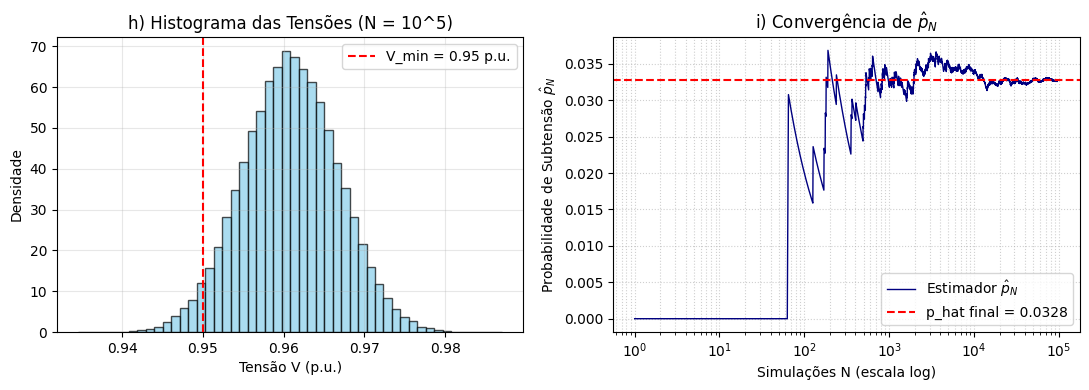

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
S_base, V0, R, X_react, fp, V_min = 500.0, 1.0, 0.13, 0.20, 0.95, 0.95
tan_phi = np.sqrt(1 - fp**2) / fp

# f) e g) Resultados estatísticos para N = 10^2 até 10^5
N_values_ex2 = [10**2, 10**3, 10**4, 10**5]
np.random.seed(42)

print("g) Métricas estatísticas de Tensão:")
print(f"{'N':<8} | {'V Média':<10} | {'Desv Padrão':<12} | {'V Min':<9} | {'V Max':<9} | {'p_hat_N':<9}")
print("-" * 68)

for N in N_values_ex2:
    # a), b) e c): amostra de P, cálculo de Q e V, e a indicadora Y
    P = np.random.normal(loc=100.0, scale=15.0, size=N)
    Q = P * tan_phi
    V = V0 - R * (P / S_base) - X_react * (Q / S_base)
    Y = np.where(V < V_min, 1, 0)
    print(f"10^{int(np.log10(N)):<5} | {np.mean(V):<10.4f} | {np.std(V):<12.5f} | {np.min(V):<9.5f} | {np.max(V):<9.5f} | {np.mean(Y):<9.4f}")

# h) e i) Gráficos para N = 10^5, reaproveitando a última amostra do laço acima
N_sim = N_values_ex2[-1]
V_sim, Y_sim = V, Y

plt.figure(figsize=(11, 4))

# Histograma
plt.subplot(1, 2, 1)
plt.hist(V_sim, bins=50, color="skyblue", edgecolor="black", alpha=0.7, density=True)
plt.axvline(V_min, color="red", linestyle="--", label=f"V_min = {V_min} p.u.")
plt.xlabel("Tensão V (p.u.)")
plt.ylabel("Densidade")
plt.title("h) Histograma das Tensões (N = 10^5)")
plt.legend()
plt.grid(True, alpha=0.3)

# Convergência
p_hat_cum = np.cumsum(Y_sim) / np.arange(1, N_sim + 1)
plt.subplot(1, 2, 2)
plt.plot(range(1, N_sim + 1), p_hat_cum, color="navy", lw=1, label=r"Estimador $\hat{p}_N$")
plt.axhline(p_hat_cum[-1], color="red", linestyle="--", label=f"p_hat final = {p_hat_cum[-1]:.4f}")
plt.xscale("log")
plt.xlabel("Simulações N (escala log)")
plt.ylabel(r"Probabilidade de Subtensão $\hat{p}_N$")
plt.title(r"i) Convergência de $\hat{p}_N$")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

### g) Análise dos resultados

| $N$ | $\bar{V}$ | $s_V$ | $V_{\min}$ | $V_{\max}$ | $\hat{p}_N$ | $\sigma_{\hat{p}_N}$ | $\lvert\hat{p}_N - p\rvert/\sigma_{\hat{p}_N}$ |
|---|---|---|---|---|---|---|---|
| $10^{2}$ | 0,9615 | 0,00531 | 0,94998 | 0,97624 | 0,0100 | 0,01768 | 1,26 |
| $10^{3}$ | 0,9606 | 0,00577 | 0,93823 | 0,97989 | 0,0370 | 0,00559 | 0,84 |
| $10^{4}$ | 0,9609 | 0,00589 | 0,93780 | 0,98389 | 0,0315 | 0,00177 | 0,45 |
| $10^{5}$ | 0,9608 | 0,00588 | 0,93455 | 0,98708 | 0,0328 | 0,00056 | 0,91 |
| - | 0,960853 | 0,005872 | - | - | 0,032289 | - | analítico |

Três comportamentos distintos aparecem na tabela:

**Momentos ($\bar{V}$ e $s_V$).** Convergem rapidamente para $\mu_V = 0{,}960853$ e $\sigma_V = 0{,}005872$: já em $N = 10^{3}$ a concordância se dá na terceira casa decimal. Para $\bar{V}$ isso é o previsto pela expressão da variância do estimador de Monte Carlo, $\operatorname{Var}(\bar{V}) = \sigma_V^{2}/N$, que faz o erro decrescer com $1/\sqrt{N}$; $s_V$ acompanha o mesmo padrão.

**Extremos ($V_{\min}$ e $V_{\max}$).** Não convergem: afastam-se à medida que $N$ cresce. $V_{\min}$ e $V_{\max}$ não estimam parâmetro nenhum: são simplesmente o menor e o maior valor sorteado. Como o suporte da Gaussiana é ilimitado, aumentar $N$ apenas aumenta a chance de sortear pontos nas caudas, e por isso os extremos se afastam indefinidamente. Não há contradição com a LFGN, que trata de médias amostrais e não de extremos.

**Probabilidade ($\hat{p}_N$).** É a grandeza mais ruidosa. Em $N = 10^{2}$ observou-se apenas **uma** violação em cem realizações, resultando $\hat{p}_N = 0{,}0100$, um erro relativo de 69% em relação ao valor analítico. As quatro estimativas, entretanto, ficam dentro de aproximadamente 1,3 vezes o desvio-padrão do próprio estimador, $\sigma_{\hat{p}_N} = \sqrt{p(1-p)/N}$, ou seja, na ordem de grandeza prevista pela expressão da variância do estimador de Monte Carlo.

A razão da lentidão está na variância relativa. Para um evento raro,

$$
\frac{\sigma_{\hat{p}_N}}{p} = \sqrt{\frac{1-p}{p\,N}} ,
$$

de modo que, com $p \approx 0{,}0323$, obter erro relativo de 10% exige $N \approx 3 \times 10^{3}$ e erro relativo de 1% exige $N \approx 3 \times 10^{5}$. É por isso que $N = 10^{2}$, suficiente para estimar a tensão média com duas casas corretas, é inútil para estimar a probabilidade de subtensão.

---

### h) Histograma das tensões

O histograma confirma o resultado analítico: a distribuição de $V$ é Gaussiana, conforme obtido pela mudança de variáveis, centrada em $0{,}9608$ p.u. O limite $V_{\min} = 0{,}95$ p.u. situa-se a $1{,}85\,\sigma_V$ à esquerda da média, e a área do histograma à esquerda da linha vermelha corresponde precisamente à probabilidade estimada $\hat{p}_N \approx 0{,}033$.

---

### i) Convergência de $\hat{p}_N$

A curva acumulada apresenta saltos discretos, cada um correspondendo a uma realização em que ocorreu subtensão, e só se estabiliza a partir de aproximadamente $10^{4}$ simulações, visivelmente mais tarde do que o estimador $\hat{I}_N$ do Exercício 1. A taxa de convergência é a mesma, $1/\sqrt{N}$, conforme a LFGN; o que difere é a constante multiplicativa, maior no caso de um evento raro pelo motivo já apresentado no item (g).

Do ponto de vista do sistema, o resultado indica que cerca de 3,2% das condições de carga violam o limite de 0,95 p.u., ou seja, aproximadamente 1 a cada 31 cenários de demanda. A margem nominal de tensão é de apenas 0,0109 p.u., o que equivale a um acréscimo de 27,7 kW sobre a demanda média, pouco mais de $1{,}8$ desvio-padrão da incerteza da carga. Isso caracteriza a regulação de tensão como fator limitante do atendimento nesse alimentador longo, conforme antecipado no enunciado.